# 삼성전자(005930) 과거 5년(2021~2025) 재무제표 종합 분석 (평가 기준 적용)
절대적/상대적 재무 건전성 평가 가이드라인을 바탕으로 삼성전자의 시계열 분석을 수행하고, 2025년 최신 데이터를 기준으로 상태를 진단합니다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

data_dir = './data/재무제표'
dart = pd.read_csv(f'{data_dir}/dart_company_2026.csv', dtype=str)
wics = pd.read_csv(f'{data_dir}/wics_company_2026.csv', dtype=str)

samsung_cmp = '005930'
samsung_dart = dart[dart['CMP_CD'] == samsung_cmp]['DART_CD'].values[0]

samsung_mkt_val = wics[wics['CMP_CD'] == samsung_cmp]['MKT_VAL'].values
samsung_mkt_val = float(samsung_mkt_val[0]) * 1000000 if len(samsung_mkt_val) > 0 else np.nan

years = ['2021', '2022', '2023', '2024', '2025']
data_list = []

for y in years:
    bs = pd.read_csv(f'{data_dir}/balance_sheet_{y}.csv', dtype=str)
    is_df = pd.read_csv(f'{data_dir}/income_statement_{y}.csv', dtype=str)
    cf = pd.read_csv(f'{data_dir}/cash_flow_{y}.csv', dtype=str)
    
    bs_s = bs[bs['corp_code'] == samsung_dart].copy()
    is_s = is_df[is_df['corp_code'] == samsung_dart].copy()
    cf_s = cf[cf['corp_code'] == samsung_dart].copy()
    
    for df in [bs_s, is_s, cf_s]:
        df['thstrm_amount'] = pd.to_numeric(df['thstrm_amount'], errors='coerce')
        df['frmtrm_amount'] = pd.to_numeric(df['frmtrm_amount'], errors='coerce')
        
    def get_val(df, acc_ids, col='thstrm_amount'):
        v = df[df['account_id'].isin(acc_ids)][col]
        return v.values[0] if len(v) > 0 else np.nan
        
    rev = get_val(is_s, ['ifrs-full_Revenue', 'dart_TotalAsset'])
    prev_rev = get_val(is_s, ['ifrs-full_Revenue', 'dart_TotalAsset'], 'frmtrm_amount')
    op = get_val(is_s, ['dart_OperatingIncomeLoss'])
    ni = get_val(is_s, ['ifrs-full_ProfitLoss'])
    
    asset = get_val(bs_s, ['ifrs-full_Assets'])
    liab = get_val(bs_s, ['ifrs-full_Liabilities'])
    eq = get_val(bs_s, ['ifrs-full_Equity'])
    cash = get_val(bs_s, ['ifrs-full_CashAndCashEquivalents'])
    
    ocf = get_val(cf_s, ['ifrs-full_CashFlowsFromUsedInOperatingActivities'])
    div = get_val(cf_s, ['ifrs-full_DividendsPaidClassifiedAsFinancingActivities'])
    if pd.isna(div): div = 0
    
    data_list.append({
        '연도': y,
        '매출액': rev, '전기매출액': prev_rev, '영업이익': op, '당기순이익': ni,
        '자산총계': asset, '부채총계': liab, '자본총계': eq, '현금성자산': cash,
        '영업활동현금흐름': ocf, '배당금지급': abs(div)
    })

df = pd.DataFrame(data_list)
latest = df[df['연도'] == '2025'].iloc[0]


## 1. 수익성 분석
* **평가 기준**: 영업이익률(OPM) 10% 이상 우수, 5% 미만 주의


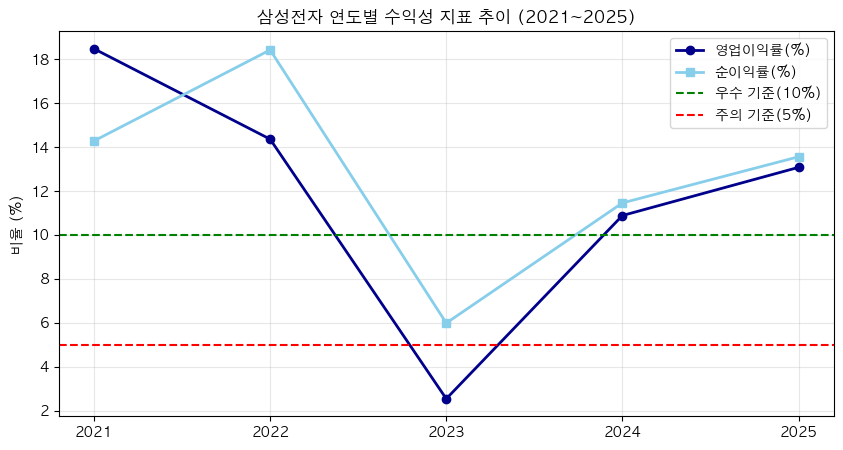

✅ [2025년 진단] 영업이익률: 13.07% -> 🟢 우수 (10% 이상)


In [2]:
df['영업이익률(%)'] = (df['영업이익'] / df['매출액']) * 100
df['순이익률(%)'] = (df['당기순이익'] / df['매출액']) * 100

plt.figure(figsize=(10, 5))
plt.plot(df['연도'], df['영업이익률(%)'], marker='o', label='영업이익률(%)', color='darkblue', linewidth=2)
plt.plot(df['연도'], df['순이익률(%)'], marker='s', label='순이익률(%)', color='skyblue', linewidth=2)
plt.axhline(10, color='green', linestyle='--', label='우수 기준(10%)')
plt.axhline(5, color='red', linestyle='--', label='주의 기준(5%)')
plt.title('삼성전자 연도별 수익성 지표 추이 (2021~2025)')
plt.ylabel('비율 (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2025년 평가
opm_2025 = df[df['연도'] == '2025']['영업이익률(%)'].values[0]
if opm_2025 >= 10:
    eval_res = "🟢 우수 (10% 이상)"
elif opm_2025 >= 5:
    eval_res = "🟡 보통 (5~10%)"
else:
    eval_res = "🔴 주의 (5% 미만)"
print(f"✅ [2025년 진단] 영업이익률: {opm_2025:.2f}% -> {eval_res}")


## 2. 성장성 분석
* **평가 기준**: 매출성장률(YoY) 10% 이상 고성장, 0% 미만 역성장(주의)


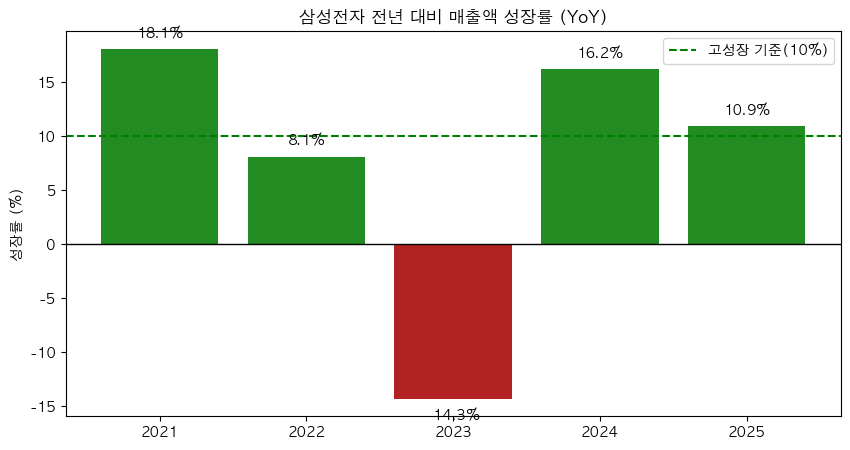

✅ [2025년 진단] 매출성장률: 10.88% -> 🟢 우수 (고성장)


In [3]:
df['매출성장률(%)'] = np.where(df['연도'] == '2021', 
                            (df['매출액'] - df['전기매출액']) / df['전기매출액'] * 100,
                            (df['매출액'] - df['매출액'].shift(1)) / df['매출액'].shift(1) * 100)

plt.figure(figsize=(10, 5))
colors = ['firebrick' if val < 0 else 'forestgreen' for val in df['매출성장률(%)']]
plt.bar(df['연도'], df['매출성장률(%)'], color=colors)
plt.axhline(10, color='green', linestyle='--', label='고성장 기준(10%)')
plt.axhline(0, color='black', linewidth=1)
plt.title('삼성전자 전년 대비 매출액 성장률 (YoY)')
plt.ylabel('성장률 (%)')
plt.legend()
for i, v in enumerate(df['매출성장률(%)']):
    plt.text(i, v + (1 if v > 0 else -2), f"{v:.1f}%", ha='center')
plt.show()

# 2025년 평가
yoy_2025 = df[df['연도'] == '2025']['매출성장률(%)'].values[0]
if yoy_2025 >= 10:
    eval_res = "🟢 우수 (고성장)"
elif yoy_2025 >= 0:
    eval_res = "🟡 보통 (저성장)"
else:
    eval_res = "🔴 주의 (역성장)"
print(f"✅ [2025년 진단] 매출성장률: {yoy_2025:.2f}% -> {eval_res}")


## 3. 재무안정성 분석
* **평가 기준**: 부채비율 100% 미만 우수(안전), 200% 초과 주의(위험)


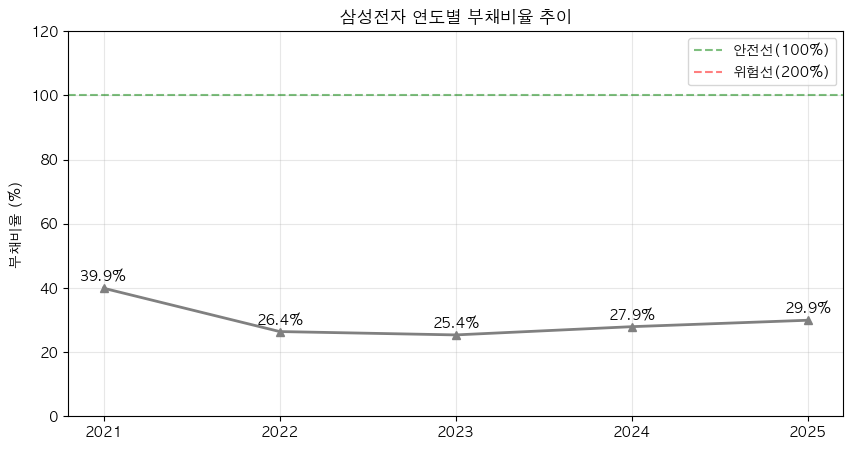

✅ [2025년 진단] 부채비율: 29.94% -> 🟢 매우 우수 (100% 미만)


In [4]:
df['부채비율(%)'] = (df['부채총계'] / df['자본총계']) * 100

plt.figure(figsize=(10, 5))
plt.plot(df['연도'], df['부채비율(%)'], marker='^', color='gray', linewidth=2)
plt.axhline(100, color='green', linestyle='--', label='안전선(100%)', alpha=0.5)
plt.axhline(200, color='red', linestyle='--', label='위험선(200%)', alpha=0.5)
plt.title('삼성전자 연도별 부채비율 추이')
plt.ylabel('부채비율 (%)')
plt.ylim(0, 120)
plt.legend()
plt.grid(True, alpha=0.3)
for i, v in enumerate(df['부채비율(%)']):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.show()

# 2025년 평가
debt_2025 = df[df['연도'] == '2025']['부채비율(%)'].values[0]
if debt_2025 < 100:
    eval_res = "🟢 매우 우수 (100% 미만)"
elif debt_2025 < 200:
    eval_res = "🟡 보통 (100~200%)"
else:
    eval_res = "🔴 주의 (200% 초과)"
print(f"✅ [2025년 진단] 부채비율: {debt_2025:.2f}% -> {eval_res}")


## 4. 현금흐름 분석
* **평가 기준**: 영업활동현금흐름 > 당기순이익 (이익의 질 우수), 영업활동현금흐름 < 0 (흑자부도 주의)


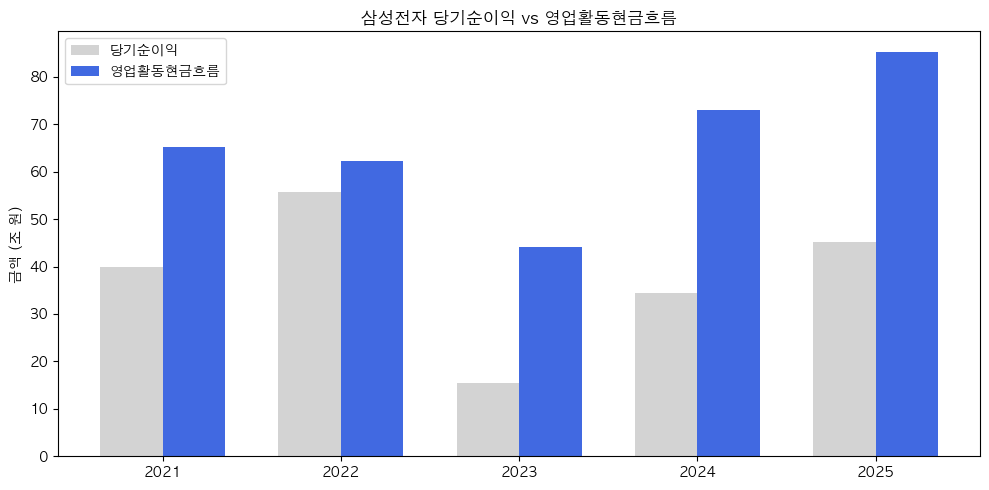

✅ [2025년 진단] OCF: 85.3조 vs NI: 45.2조 -> 🟢 우수 (영업현금흐름 > 순이익, 이익의 질 매우 높음)


In [5]:
width = 0.35
x = np.arange(len(df['연도']))

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, df['당기순이익'] / 1e12, width, label='당기순이익', color='lightgray')
rects2 = ax.bar(x + width/2, df['영업활동현금흐름'] / 1e12, width, label='영업활동현금흐름', color='royalblue')

ax.set_ylabel('금액 (조 원)')
ax.set_title('삼성전자 당기순이익 vs 영업활동현금흐름')
ax.set_xticks(x)
ax.set_xticklabels(df['연도'])
ax.legend()
fig.tight_layout()
plt.show()

# 2025년 평가
ocf_2025 = df[df['연도'] == '2025']['영업활동현금흐름'].values[0]
ni_2025 = df[df['연도'] == '2025']['당기순이익'].values[0]

if ocf_2025 < 0:
    eval_res = "🔴 위험 (영업현금흐름 적자)"
elif ocf_2025 > ni_2025:
    eval_res = "🟢 우수 (영업현금흐름 > 순이익, 이익의 질 매우 높음)"
else:
    eval_res = "🟡 보통 (영업현금흐름 흑자이나 순이익 하회)"
print(f"✅ [2025년 진단] OCF: {ocf_2025/1e12:.1f}조 vs NI: {ni_2025/1e12:.1f}조 -> {eval_res}")


## 5. 밸류에이션 분석
* **평가 기준**: 통상 PER 10배 이하, PBR 1배 이하 시 자산 및 이익 가치 대비 저평가(가치주) 영역으로 판단.


In [6]:
if not pd.isna(samsung_mkt_val):
    per_2025 = samsung_mkt_val / latest['당기순이익'] if latest['당기순이익'] > 0 else np.nan
    pbr_2025 = samsung_mkt_val / latest['자본총계']

    print(f"▶ 현재 시가총액: {samsung_mkt_val/1e12:.1f} 조 원")
    print("-" * 40)
    
    per_eval = "🟢 저평가 (10배 미만)" if per_2025 < 10 else ("🟡 적정/프리미엄" if per_2025 < 20 else "🔴 고평가/어닝쇼크")
    print(f"✅ [2025 실적 기준] PER: {per_2025:.1f} 배 -> {per_eval}")
    
    pbr_eval = "🟢 저평가 (1배 미만)" if pbr_2025 < 1 else "🟡 1배 이상"
    print(f"✅ [2025 실적 기준] PBR: {pbr_2025:.2f} 배 -> {pbr_eval}")


▶ 현재 시가총액: 570.5 조 원
----------------------------------------
✅ [2025 실적 기준] PER: 12.6 배 -> 🟡 적정/프리미엄
✅ [2025 실적 기준] PBR: 1.31 배 -> 🟡 1배 이상


## 6. 주주환원 분석
* **평가 기준**: 배당수익률이 시중 예금금리(약 3%)를 상회할 시 고배당주로 평가.


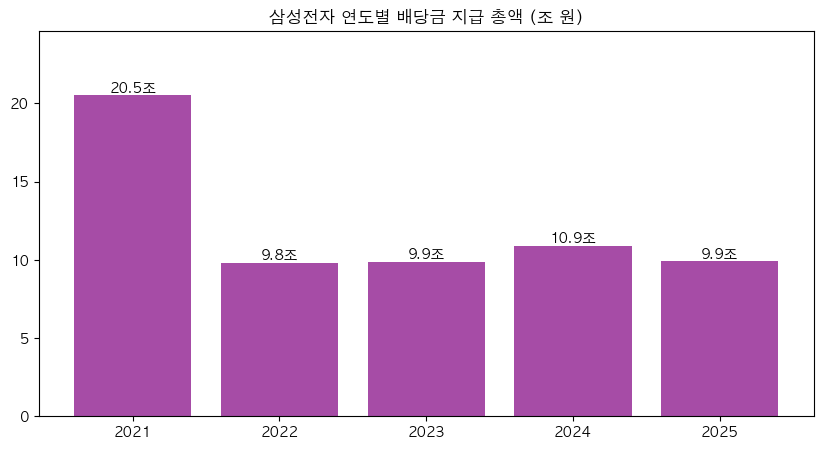

✅ [2025 지급 배당금 기준] 추정 배당수익률: 1.73% -> 🟡 보통 (1~3%)


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(df['연도'], df['배당금지급'] / 1e12, color='purple', alpha=0.7)
plt.title('삼성전자 연도별 배당금 지급 총액 (조 원)')
for i, v in enumerate(df['배당금지급'] / 1e12):
    plt.text(i, v + 0.2, f"{v:.1f}조", ha='center')
plt.ylim(0, (df['배당금지급'].max() / 1e12) * 1.2)
plt.show()

# 2025년 배당금 기준 시가배당률 (현재 시가총액 대비)
div_2025 = latest['배당금지급']
if not pd.isna(samsung_mkt_val) and samsung_mkt_val > 0:
    yield_2025 = (div_2025 / samsung_mkt_val) * 100
    
    if yield_2025 >= 3.0:
        eval_res = "🟢 우수 (시중 금리 상회 고배당)"
    elif yield_2025 >= 1.0:
        eval_res = "🟡 보통 (1~3%)"
    else:
        eval_res = "🔴 아쉬움 (1% 미만)"
    print(f"✅ [2025 지급 배당금 기준] 추정 배당수익률: {yield_2025:.2f}% -> {eval_res}")
